In [1]:
!pip install tensorflow matplotlib numpy scikit-learn

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix


In [3]:
DATA_DIR = "dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

training_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 82 files belonging to 3 classes.


Using 66 files for training.
Found 82 files belonging to 3 classes.
Using 16 files for validation.


In [4]:
class_names = training_dataset.class_names

print("Classes:", class_names)

Classes: ['approved', 'peace', 'wave']


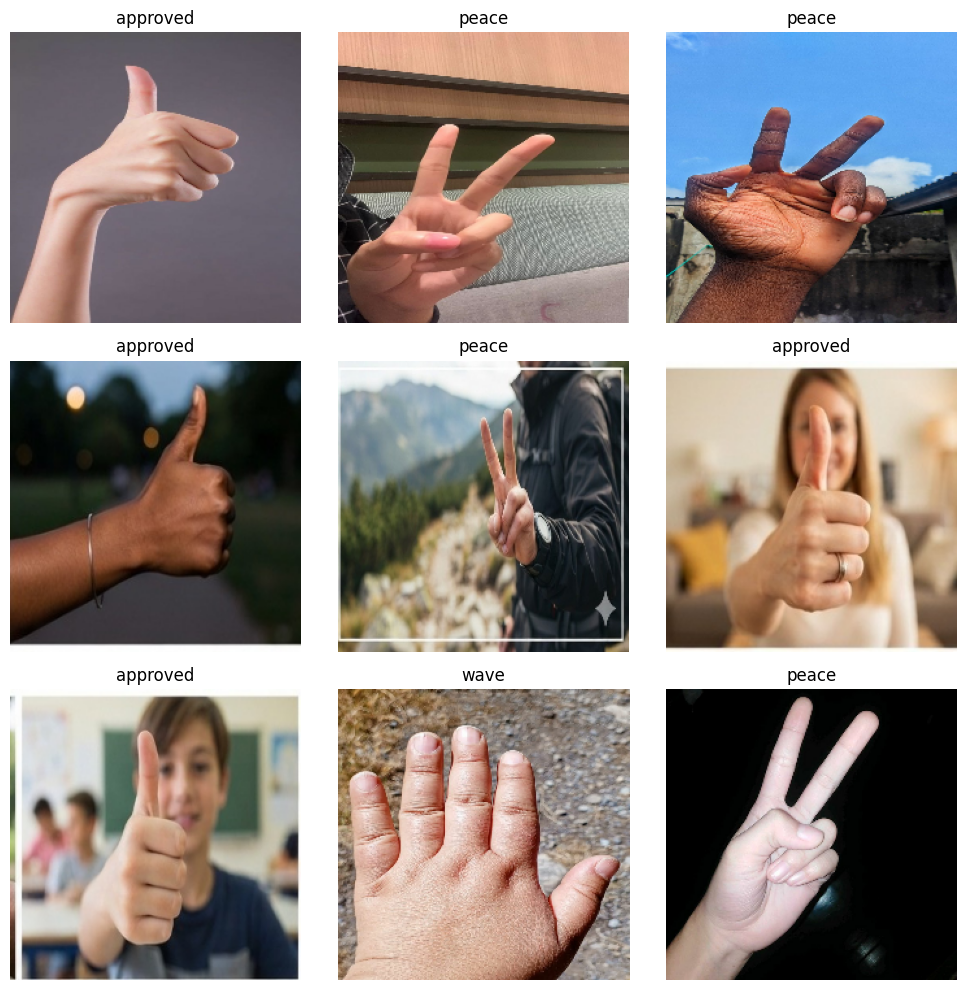

In [5]:
# to see what we're feeding the model ...
plt.figure(figsize=(10, 10))

for images, labels in training_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = training_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
# .....this just makes loading the images more efficient


In [7]:
# make the model more robust
# it it should not memorize like this exact background + this exact hand position = this class
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])
# ⚠️ A vertically flipped hand could produce something unrealistic and teach the model unnecessary patterns

In [8]:
# the interesting part: using a model that has alreay learned useful features from a huge dataset (ImageNet) and applying it to this smaller dataset
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [9]:
# MobileNetV2 wasn't trained to recognize our classes, so we need to add a new classification layer for our specific task
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

In [10]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# compiling the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [12]:
# training the model
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.3939 - loss: 1.3733 - val_accuracy: 0.1250 - val_loss: 1.5219
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 807ms/step - accuracy: 0.3636 - loss: 1.3398 - val_accuracy: 0.1250 - val_loss: 1.5117
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 794ms/step - accuracy: 0.3788 - loss: 1.3777 - val_accuracy: 0.1250 - val_loss: 1.5103
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 879ms/step - accuracy: 0.3636 - loss: 1.3516 - val_accuracy: 0.0625 - val_loss: 1.5108
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 880ms/step - accuracy: 0.4091 - loss: 1.3060 - val_accuracy: 0.0625 - val_loss: 1.5149
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 814ms/step - accuracy: 0.3182 - loss: 1.4836 - val_accuracy: 0.0625 - val_loss: 1.5237
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 850ms/step - accuracy: 0.2727 - loss: 1.3631 - val_accuracy: 0.0625 - val_loss: 1.5243
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 778ms/step - accuracy: 0.3485 - loss: 1.3567 - val_accuracy: 0.0625 - val_loss: 1.5249
Epoch

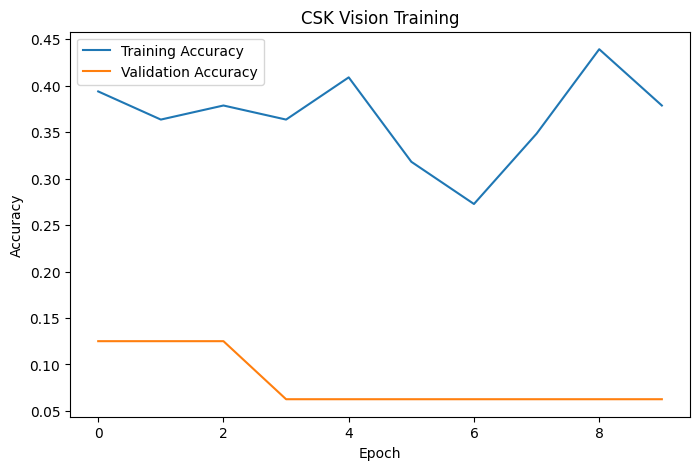

In [13]:
# visualizing 
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CSK Vision Training")
plt.legend()

plt.show()

In [14]:
# evaluate the model
loss, accuracy = model.evaluate(validation_dataset)

print(f"Validation accuracy: {accuracy:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step - accuracy: 0.0625 - loss: 1.5177
Validation accuracy: 6.25%


In [15]:
# confusion matrix
y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))



In [16]:
cm = confusion_matrix(y_true, y_pred)

print(cm)


[[1 6 0]
 [2 0 1]
 [1 5 0]]


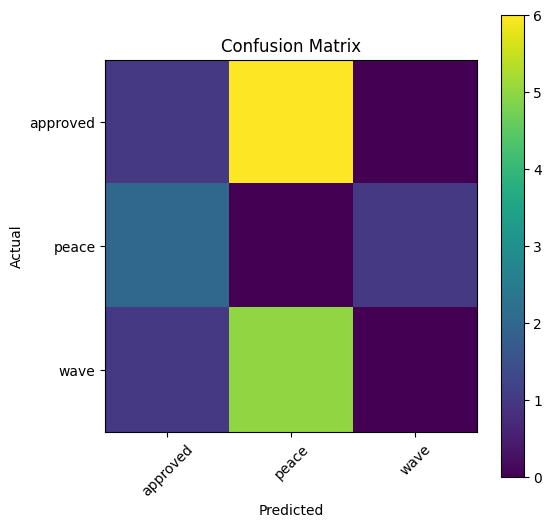

In [17]:
# nicer visualiztion
plt.figure(figsize=(6, 6))

plt.imshow(cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

In [18]:
# classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    approved       0.25      0.14      0.18         7
       peace       0.00      0.00      0.00         3
        wave       0.00      0.00      0.00         6

    accuracy                           0.06        16
   macro avg       0.08      0.05      0.06        16
weighted avg       0.11      0.06      0.08        16



In [19]:
# saving the model
model.save("csk_vision_model.keras")